Shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Diagnosis distribution:
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64

Missing values per column:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean  

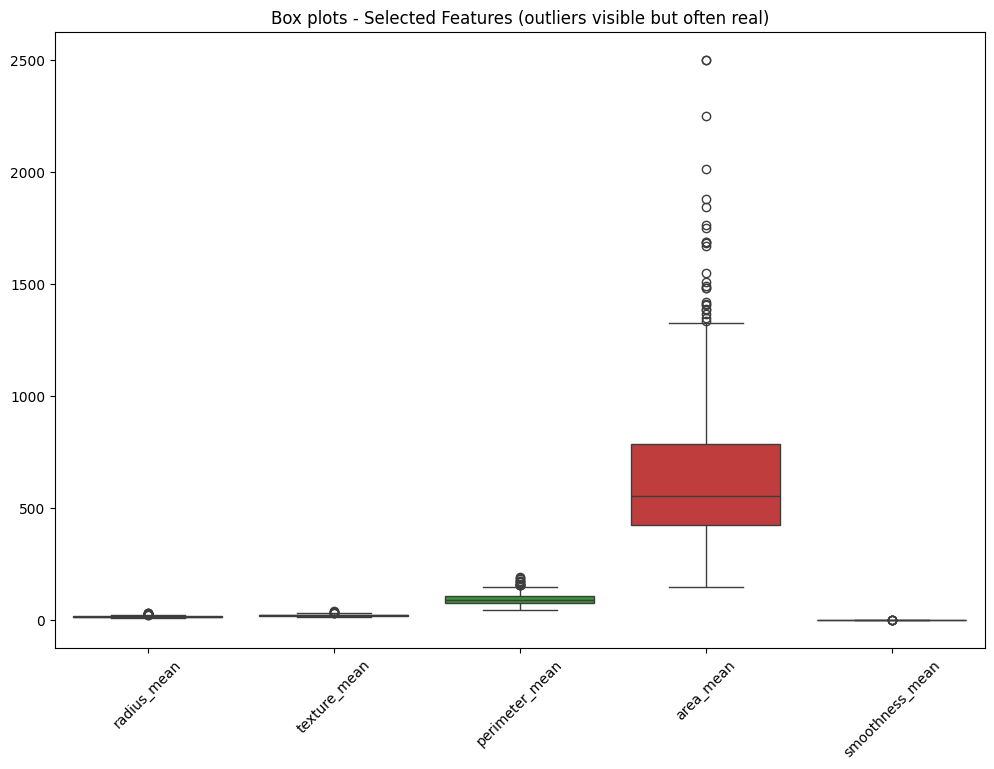


Split sizes:
Train: 398 samples (148 malignant)
Validation: 85 samples
Test: 86 samples


In [9]:

#Data Preprocessing - Breast Cancer Wisconsin Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
# Load the data
df = pd.read_csv('data.csv')  # Adjust path if needed, e.g., 'path/to/data.csv'

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDiagnosis distribution:")
print(df['diagnosis'].value_counts(normalize=True).round(3))

# Clean up
# Drop 'id' (not required for modeling) and any empty column like 'Unnamed: 32'
df = df.drop(columns=['id'], errors='ignore')
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

# Encode target: M=1 (malignant), B=0 (benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

#Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# This dataset is clean, no imputation needed

# Quick outlier inspection (boxplots for a few features)
# Selecting a few representative features
features_sample = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[features_sample])
plt.title('Box plots - Selected Features (outliers visible but often real)')
plt.xticks(rotation=45)
plt.show()

# I am keeping outliers (they represent extreme cases in real radiology)

# Features & Target
X = df.drop('diagnosis', axis=1)          # All 30 numeric features
y = df['diagnosis']                       # Binary target

# Scaling features (very important for ANN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train / Validation / Test split
# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\nSplit sizes:")
print(f"Train: {X_train.shape[0]} samples ({len(y_train[y_train==1])} malignant)")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

In [10]:

# Installing TensorFlow/Keras

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Installation successful!")


TensorFlow version: 2.20.0
Installation successful!


In [11]:

# Step 3: Build the ANN Model
# Breast Cancer Diagnosis - TensorFlow/Keras


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

# Define the model
model = Sequential(name='Breast_Cancer_ANN')

# Input layer + first hidden block
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))  # 30 features
model.add(BatchNormalization())  # Helps stabilize and speed up training
model.add(Dropout(0.3))          # Dropout to reduce overfitting

# Second hidden block
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Third hidden layer (optional – smaller network for this dataset size)
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

# Output layer – binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Model summary
model.summary()

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,                  # More patience than before
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

print("\nModel ready for training.")

TensorFlow version: 2.20.0


C:\Users\HP\Dropbox\MSDA\Course 7 - Machine Learning for Business Analytics\Module 5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Breast_Cancer_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 96 (384.00 B)


Model ready for training. You can now run model.fit(...) in Step 4.


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9497 - auc: 0.9891 - loss: 0.1290 - precision: 0.9444 - recall: 0.9189 - val_accuracy: 0.9647 - val_auc: 0.9932 - val_loss: 0.0926 - val_precision: 1.0000 - val_recall: 0.9062
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9623 - auc: 0.9934 - loss: 0.1102 - precision: 0.9716 - recall: 0.9257 - val_accuracy: 0.9647 - val_auc: 0.9929 - val_loss: 0.1031 - val_precision: 1.0000 - val_recall: 0.9062
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9623 - auc: 0.9908 - loss: 0.1124 - precision: 0.9650 - recall: 0.9324 - val_accuracy: 0.9647 - val_auc: 0.9932 - val_loss: 0.0970 - val_precision: 1.0000 - val_recall: 0.9062
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9598 - auc: 0.9831 - loss: 0.1352 - precision: 0.9583 - recall: 0.9324 - val_accuracy: 0.9647 - val_auc: 0.9920 - val_loss: 0.0946 - val_precision: 1.0000 - val_recall: 0.9062
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━

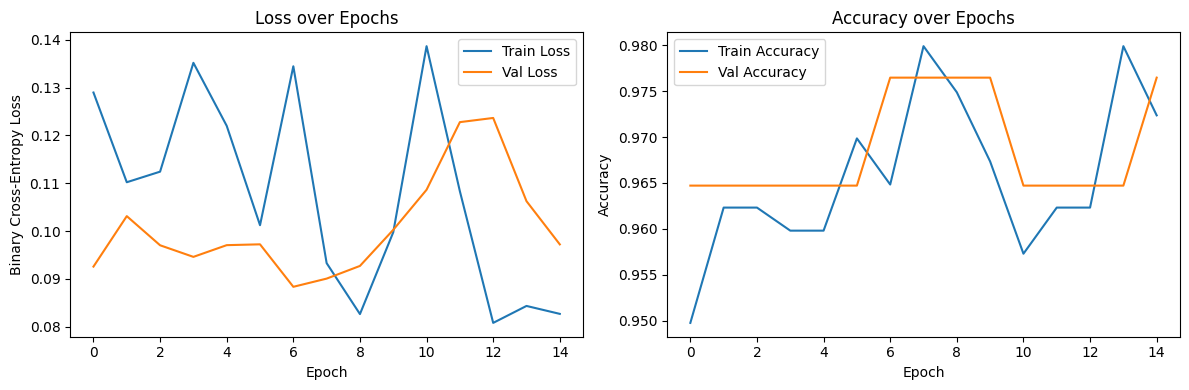

Validation Loss:      0.0926
Validation Accuracy:  0.9647
Validation AUC:       0.9932
Validation Precision: 1.0000
Validation Recall:    0.9062


In [13]:

# Step 4: Train the ANN Model

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,               # High enough; early stopping will halt
    batch_size=32,            # Common good size for this dataset
    callbacks=[early_stopping],
    verbose=1                 # Shows progress per epoch
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Printing final validation metrics
# Evaluating on validation set
val_results = model.evaluate(X_val, y_val, verbose=0)

# Unpacking all values (loss + 4 metrics)
val_loss = val_results[0]
val_accuracy = val_results[1]
val_auc = val_results[2]
val_precision = val_results[3]
val_recall = val_results[4]

print(f"Validation Loss:      {val_loss:.4f}")
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation AUC:       {val_auc:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")

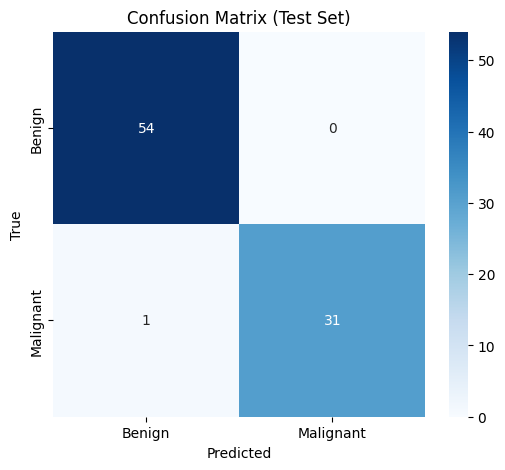


Classification Report (Test Set):
               precision    recall  f1-score   support

   Benign (0)       0.98      1.00      0.99        54
Malignant (1)       1.00      0.97      0.98        32

     accuracy                           0.99        86
    macro avg       0.99      0.98      0.99        86
 weighted avg       0.99      0.99      0.99        86



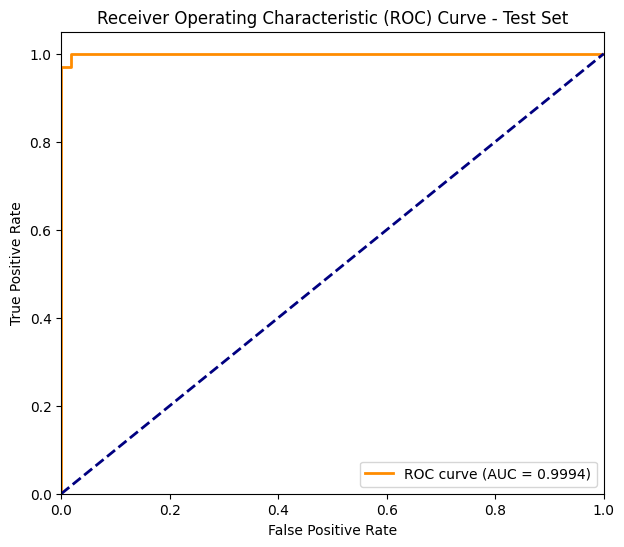


Final Test Set Performance:
Loss:      0.0578
Accuracy:  0.9884
AUC:       0.9994
Precision: 1.0000
Recall:    0.9688


In [14]:

# Step 5: Evaluation on Test Set

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predicting on test set
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # threshold 0.5

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 3. Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

# 4. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc='lower right')
plt.show()

# 5. Final test metrics summary
test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
print("\nFinal Test Set Performance:")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"AUC:       {test_auc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")

In [15]:

# Step 6: Improvement – Class Weights + LR Scheduler


from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau

#Computing class weights to give more importance to malignant class
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)  # Malignant gets higher weight

#Learning rate reducer (reduces LR when val loss plateaus)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

#Re-training with improvements using same model architecture)
history_improved = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,                 # Giving it more room
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# Re-evaluating on test set after improved training
y_pred_prob_new = model.predict(X_test, verbose=0)
y_pred_new = (y_pred_prob_new > 0.5).astype(int).flatten()

print("\nImproved Classification Report (Test Set):")
print(classification_report(y_test, y_pred_new, target_names=['Benign (0)', 'Malignant (1)']))

test_loss_new, test_acc_new, test_auc_new, test_prec_new, test_rec_new = model.evaluate(X_test, y_test, verbose=0)
print("\nImproved Test Metrics:")
print(f"Loss:      {test_loss_new:.4f}")
print(f"Accuracy:  {test_acc_new:.4f}")
print(f"AUC:       {test_auc_new:.4f}")
print(f"Precision: {test_prec_new:.4f}")
print(f"Recall:    {test_rec_new:.4f}")

Class weights: {0: np.float64(0.796), 1: np.float64(1.3445945945945945)}
Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9523 - auc: 0.9862 - loss: 0.1495 - precision: 0.9510 - recall: 0.9189 - val_accuracy: 0.9765 - val_auc: 0.9938 - val_loss: 0.0889 - val_precision: 1.0000 - val_recall: 0.9375 - learning_rate: 0.0010
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9673 - auc: 0.9936 - loss: 0.1120 - precision: 0.9720 - recall: 0.9392 - val_accuracy: 0.9765 - val_auc: 0.9941 - val_loss: 0.0882 - val_precision: 1.0000 - val_recall: 0.9375 - learning_rate: 0.0010
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9573 - auc: 0.9906 - loss: 0.1321 - precision: 0.9517 - recall: 0.9324 - val_accuracy: 0.9765 - val_auc: 0.9938 - val_loss: 0.0866 - val_precision: 1.0000 - val_recall: 0.9375 - learning_rate: 0.0010
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9774 - auc: 0.9927 - loss: 0.1068 - precision: 0.9728 - recall: